<a href="https://colab.research.google.com/github/inhwan-sul/CAREER_VSCODE/blob/main/kit_career.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **신임교원 채용 경력 계산기**

(0) 코랩에서 한글 폰트 설치(제일 처음 한 번만).
- 아래 셀을 실행한 후, "메인 메뉴-->런타임-->세션 다시 시작"을 누릅니다.

In [4]:
import sys
in_colab = 'google.colab' in sys.modules
if in_colab:
  !sudo apt-get install -y fonts-nanum
  !sudo fc-cache -fv
  !rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

(1) 엑셀 업로드
- 왼쪽 구글 드라이브의 "content" 폴더에 엑셀 파일을 업로드합니다.
- 셀 순서는 바꾸면 안 됩니다.
- 소스코드의 파일 이름 부분( pd.read_excel('/content/careeer_data_sample.xlsx') 을 올린 파일에 맞게 수정하세요

![def](https://github.com/inhwan-sul/CAREER_VSCODE/blob/main/excel_copy_example.png?raw=1)

(2) 엑셀 파일을 읽습니다.

<Figure size 640x480 with 0 Axes>

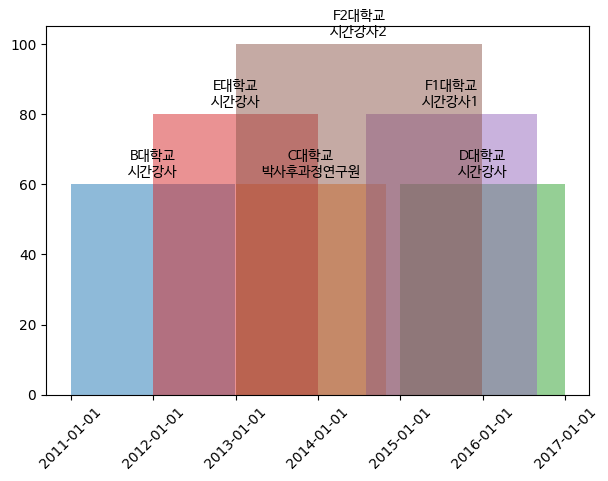

,A대학교,특강강사(영어강의),2010-01-01 00:00:00,2019-12-31 00:00:00,30
0,B대학교,시간강사,2011-01-01,2012-12-31,60
1,C대학교,박사후과정연구원,2013-01-01,2014-10-31,60
2,D대학교,시간강사,2015-01-01,2016-12-31,60
3,E대학교,시간강사,2012-01-01,2013-12-31,80
4,F1대학교,시간강사1,2014-08-01,2016-08-28,80
5,F2대학교,시간강사2,2013-01-01,2015-12-31,100


In [3]:
from datetime import date, datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import pandas as pd
from typing import Self


class Job:
    def __init__(self, office_name : str, title : str,  interval : pd.Interval, weight : float):
        self.office_name    = office_name
        self.title          = title
        self.interval       = interval
        self.weight         = weight * 1. # to percentage

    @classmethod
    def from_pd(cls, pd_data : pd.Series) -> Self:
        return cls(
            office_name = pd_data[0],
            title       = pd_data[1],
            interval    = date_to_interval(pd_data[2], pd_data[3]),
            weight      = pd_data[4])

    @classmethod
    def copy(cls, source : Self) -> Self:
        return cls(source.office_name, source.title, source.interval, source.weight)

    # def print_it(self):
    #     print(self.office_name, self.title, str(self.interval.left), str(self.interval.right), self.weight)

def date_to_interval(start_date_str : str, end_date_str : str) -> pd.Interval:
    start_date = pd.Timestamp(pd.to_datetime(start_date_str))
    end_date   = pd.Timestamp(pd.to_datetime(end_date_str))
    return pd.Interval(start_date, end_date, closed='both')

def is_better_career(job1 : Job, job2 : Job) -> bool:
    return (job1.interval.left <= job2.interval.left
       and job2.interval.right <= job1.interval.right
       and job1.weight > job2.weight)

def is_next_to(job1 : Job, job2 : Job) -> Job:
    if (    job1.office_name == job2.office_name
        and job1.title == job2.title
        and job1.weight == job2.weight
        and job1.interval.right == job2.interval.left
        ):
        return True

def update(old_jobs : list[Job], new_job : Job) -> list[Job]:
    for o_job in old_jobs:
        if is_next_to(o_job, new_job):
            o_job.interval = pd.Interval(o_job.interval.left, new_job.interval.right, closed='both')
            return old_jobs
    old_jobs.append(new_job)
    return old_jobs

def count_days(jobs : list[Job]) -> float:
    days = sum([(job.interval.right - job.interval.left).days * job.weight / 100. for job in jobs])
    years = days // 365
    remaining_days = days % 365
    months = remaining_days // 30
    days = remaining_days % 30
    print(f"※ 유효 경력 = {years} years, {months} months, and {days} days")


def plot(jobs : list[Job]):
  import matplotlib.pyplot as plt
  plt.clf()
  _, ax = plt.subplots()
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.rc('font', family='NanumBarunGothic')
  plt.rcParams['axes.unicode_minus'] =False

  bar_x = [job.interval.left for job in jobs]
  bar_H = [job.weight for job in jobs]
  bar_W = [(job.interval.right - job.interval.left).days for job in jobs]
  bar_label = [f"{job.office_name}\n{job.title}" for job in jobs]
  colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
  bars = ax.bar(bar_x, bar_H, width=bar_W, label=bar_label, align='edge', alpha=0.5, linewidth=2, color = colors[:len(jobs)])
  ax.bar_label(bars, labels=bar_label, padding=3)
  plt.show()



# df = pd.read_clipboard(header=None) # 로컬 PC에서 실행할 때에는 그냥 붙여넣기로 하는 게 편합니다.
df = pd.read_excel('/content/careeer_data_sample.xlsx') #코랩에서 사용할 경우
jobs = [Job.from_pd(pd_data) for pd_data in df.itertuples(index=False)]
plot(jobs)
display(df)


(3) 유효 경력을 계산합니다.
- 윤년 등을 고려하지 않았기 때문에 달력을 기준으로 한 날짜와 1~2일 정도의 오차가 있을 수 있습니다.

<Figure size 640x480 with 0 Axes>

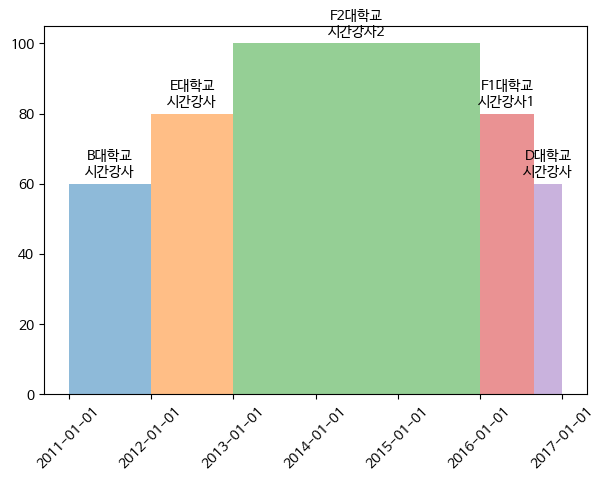

,office_name,title,start_date,end_date,weight,days
0,B대학교,시간강사,2011-01-01,2012-01-01,60.0,219.0
1,E대학교,시간강사,2012-01-01,2013-01-01,80.0,292.8
2,F2대학교,시간강사2,2013-01-01,2015-12-31,100.0,1094.0
3,F1대학교,시간강사1,2015-12-31,2016-08-28,80.0,192.8
4,D대학교,시간강사,2016-08-28,2016-12-31,60.0,75.0


※ 유효 경력 = 5.0 years, 1.0 months, and 18.59999999999991 days


In [4]:
#decompose jobs into non-overlapping intervals
points = pd.concat([df[df.columns[2]], df[df.columns[3]]]).sort_values().unique()
(new_starts, new_ends) = points[:-1], points[1:]
new_intervals = [date_to_interval(start, end) for start, end in zip(new_starts, new_ends)]

#update weights of the new intervals
new_jobs = []
for new_id, new_intv in enumerate(new_intervals):
    best_career_in_the_new_interval = Job( "", "", new_intv, 0.)
    for job in jobs:
        if is_better_career(job, best_career_in_the_new_interval):
            best_career_in_the_new_interval.office_name = job.office_name
            best_career_in_the_new_interval.title       = job.title
            best_career_in_the_new_interval.weight      = job.weight

    if best_career_in_the_new_interval.weight > 0:
        update(new_jobs, best_career_in_the_new_interval)

new_df = pd.DataFrame({
    "office_name": [job.office_name for job in new_jobs],
    "title": [job.title for job in new_jobs],
    "start_date": [job.interval.left for job in new_jobs],
    "end_date": [job.interval.right for job in new_jobs],
    "weight": [job.weight for job in new_jobs]
})
new_df['days']= (new_df['end_date'] - new_df['start_date']).dt.days * new_df['weight'] / 100.
plot( new_jobs)
display(new_df)
count_days(new_jobs)